In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

# 07 — 3D Safe Zone Evolution: A Third Parameter Axis

The `PrintabilitySpace.plot_3d_safe_zone()` method extends the standard 2D map into a third
dimension — revealing how the safe printing zone grows or shrinks as an additional process
parameter changes. This notebook demonstrates two cases: varying beam radius and varying
layer thickness.

---

## Section 1 — Imports and Material Setup

A 3D evaluation grid requires a 3D `ProcessParameters` object. The three axes are arranged
using NumPy shape broadcasting:

- **Axis 0 (dim 0):** laser_power — column vector shape `(N, 1, 1)`
- **Axis 1 (dim 1):** scan_speed — row vector shape `(1, M, 1)`
- **Axis 2 (dim 2):** third parameter (beam_radius or layer_thickness) — depth vector `(1, 1, K)`

The resulting `ProcessParameters.shape` is `(N, M, K)`, and `space.defect_map.shape` matches
exactly.

In [2]:
import numpy as np

from lpbf_map import Material, ProcessParameters, MeltPool, PrintabilitySpace
from lpbf_map.defects import (
    DefectSuite,
    LackOfFusionCriterion,
    BallingPlateauRayleighCriterion,
    KeyholeGanCriterion,
)

# Load Ti-6Al-4V from the built-in library
material = Material.from_library('Ti64')

print(f'Material : {material.name}')
print(f'T_melt   : {material.melting_temperature} K')


def build_standard_suite():
    """Helper: returns a DefectSuite with the standard three criteria."""
    suite = DefectSuite()
    suite.add(1, BallingPlateauRayleighCriterion())
    suite.add(2, LackOfFusionCriterion())
    suite.add(3, KeyholeGanCriterion())
    return suite

Material : Ti-6Al-4V
T_melt   : 1877.0 K


---

## Section 2 — Building a 3D Parameter Grid (P, v, beam_radius)

Each parameter vector is reshaped to occupy a unique array axis using `np.newaxis`. NumPy's
broadcasting then expands all three to the shared `(15, 15, 3)` shape automatically — no
explicit `np.meshgrid` call is needed.

- **`laser_powers`**: shape `(15, 1, 1)` — 15 power levels from 100 to 350 W
- **`scan_speeds`**: shape `(1, 15, 1)` — 15 speed levels from 0.5 to 2.5 m/s
- **`beam_radii`**: shape `(1, 1, 3)` — 3 discrete beam radii: 30, 50, 70 µm

This yields **15 × 15 × 3 = 675 evaluation points** across the defect map.

In [3]:
# Axis 0: laser power (15 levels)  — shape (15, 1, 1)
laser_powers = np.linspace(100, 350, 15)[:, np.newaxis, np.newaxis]

# Axis 1: scan speed (15 levels)    — shape (1, 15, 1)
scan_speeds = np.linspace(0.5, 2.5, 15)[np.newaxis, :, np.newaxis]

# Axis 2: beam radius (3 values)    — shape (1, 1, 3)
beam_radii = np.array([30e-6, 50e-6, 70e-6])[np.newaxis, np.newaxis, :]

params = ProcessParameters(
    laser_power=laser_powers,
    scan_speed=scan_speeds,
    beam_radius=beam_radii,
    hatch_spacing=90e-6,     # fixed [m]
    layer_thickness=30e-6    # fixed [m]
)

print(f'3D parameter grid shape: {params.shape}')  # -> (15, 15, 3)

3D parameter grid shape: (15, 15, 3)


---

## Section 3 — Evaluate the 3D Defect Map

The evaluation loop in `PrintabilitySpace.evaluate()` uses `np.ndindex(shape)` internally,
so it generalises seamlessly to 3D grids without any API changes.

675 physics solver calls are made — expect a runtime of roughly **5–15 minutes** depending
on hardware. The result is cached in `space.defect_map`.

In [4]:
pool = MeltPool(material, params)
suite = build_standard_suite()
space = PrintabilitySpace(pool, suite)

# Evaluate all 675 grid points — this is the computationally intensive step
space.evaluate()

print(f'Defect map shape : {space.defect_map.shape}')  # -> (15, 15, 3)

# space.len() counts entries along the first dimension of the named parameter
print(f'Unique beam radii: {space.len("beam_radius")} (scalar broadcasted to each layer)')

import numpy as np
unique, counts = np.unique(space.defect_map, return_counts=True)
print('\nGrid breakdown across all layers:')
for uid, cnt in zip(unique, counts):
    print(f'  {space.defect_labels[uid]:20s}: {cnt:5d} points ({100*cnt/space.defect_map.size:.1f}%)')

Defect map shape : (15, 15, 3)
Unique beam radii: 1 (scalar broadcasted to each layer)

Grid breakdown across all layers:
  Safe                :   117 points (17.3%)
  BallingPlateauRayleigh:   330 points (48.9%)
  LackOfFusion        :   144 points (21.3%)
  KeyholeGan          :    84 points (12.4%)


---

## Section 4 — Plot the 3D Safe Zone Evolution

`plot_3d_safe_zone()` renders the defect map as **stacked 2D contour layers** in 3D space:

- The **base layer** (lowest beam_radius value) shows the full defect map — all regions
  (safe, balling, LOF, keyhole) — as a reference.
- **Higher layers** show only the **safe zone** (defect code 0), rendered with reduced
  opacity so the base layer remains visible through them.

This makes it immediately clear how the safe zone evolves: a larger beam radius at the same
power deposits more energy per unit length, favourably expanding the safe zone at the cost
of lateral resolution.

The method signature is:
```python
space.plot_3d_safe_zone(x_axis='scan_speed', y_axis='laser_power', z_axis='beam_radius')
```
where all axis names are `ProcessParameters` field names.

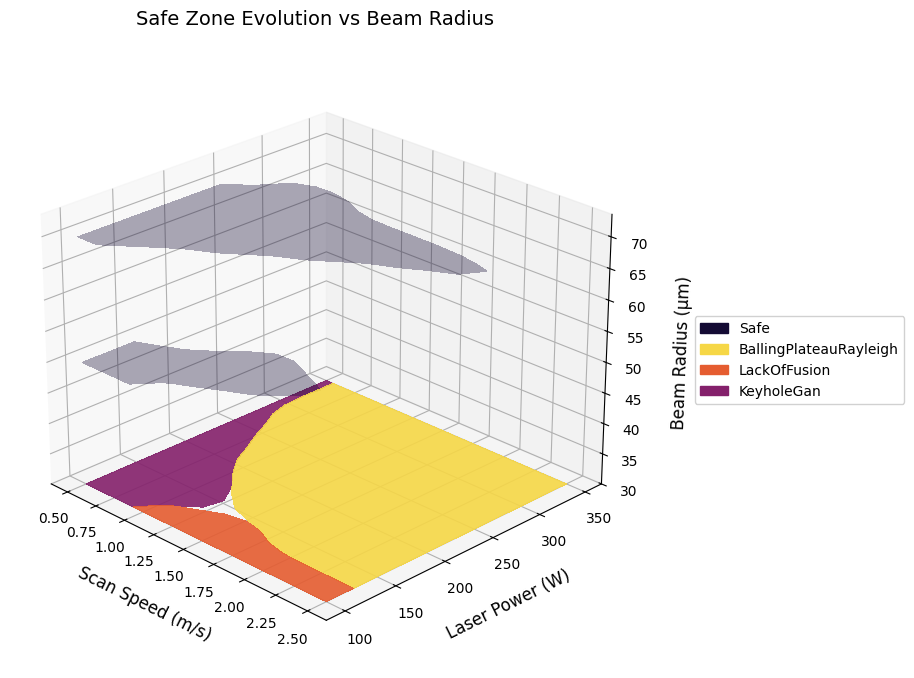

In [5]:
# Plot the 3D safe zone evolution vs beam radius
# x_axis -> scan_speed (horizontal), y_axis -> laser_power (depth), z_axis -> beam_radius
fig, ax = space.plot_3d_safe_zone(
    x_axis='scan_speed', 
    y_axis='laser_power', 
    z_axis='beam_radius',
    save_path='plots/ti64_3d_beam_radius.png'
    )

---

## Section 5 — Layer Thickness as the Third Axis

Layer thickness directly controls the **Lack-of-Fusion boundary**: the melt pool must
penetrate at least one layer thickness into the substrate to fuse it. As layer thickness
increases, the minimum depth required increases, and the LOF region expands toward higher
powers.

Here we build a `(15, 15, 4)` grid:
- **Axis 0:** laser_power — 15 levels from 100 to 350 W
- **Axis 1:** scan_speed  — 15 levels from 0.5 to 2.5 m/s
- **Axis 2:** layer_thickness — 4 values: 20, 30, 40, 50 µm

Each 2D slice in the 3D plot corresponds to a different deposited powder thickness.
As layer thickness increases, the LOF boundary retreats into the safe zone from below,
shrinking the operating window.

In [6]:
# Axis 0: laser power (15 levels)    — shape (15, 1, 1)
laser_powers_lt = np.linspace(100, 350, 15)[:, np.newaxis, np.newaxis]

# Axis 1: scan speed (15 levels)     — shape (1, 15, 1)
scan_speeds_lt = np.linspace(0.5, 2.5, 15)[np.newaxis, :, np.newaxis]

# Axis 2: layer thickness (4 values) — shape (1, 1, 4)
layer_thicknesses = np.array([20e-6, 30e-6, 40e-6, 50e-6])[np.newaxis, np.newaxis, :]

params_lt = ProcessParameters(
    laser_power=laser_powers_lt,
    scan_speed=scan_speeds_lt,
    beam_radius=50e-6,           # fixed [m]
    hatch_spacing=80e-6,         # fixed [m]
    layer_thickness=layer_thicknesses
)

print(f'3D grid shape (P x v x t): {params_lt.shape}')  # -> (15, 15, 4)

3D grid shape (P x v x t): (15, 15, 4)


In [7]:
pool_lt = MeltPool(material, params_lt)
suite_lt = build_standard_suite()
space_lt = PrintabilitySpace(pool_lt, suite_lt)

# Evaluate 15 x 15 x 4 = 900 grid points
space_lt.evaluate()

print(f'Defect map shape : {space_lt.defect_map.shape}')  # -> (15, 15, 4)

unique, counts = np.unique(space_lt.defect_map, return_counts=True)
print('\nGrid breakdown (all layer thicknesses combined):')
for uid, cnt in zip(unique, counts):
    print(f'  {space_lt.defect_labels[uid]:20s}: {cnt:5d} points ({100*cnt/space_lt.defect_map.size:.1f}%)')

Defect map shape : (15, 15, 4)

Grid breakdown (all layer thicknesses combined):
  Safe                :   135 points (15.0%)
  BallingPlateauRayleigh:   452 points (50.2%)
  LackOfFusion        :   201 points (22.3%)
  KeyholeGan          :   112 points (12.4%)


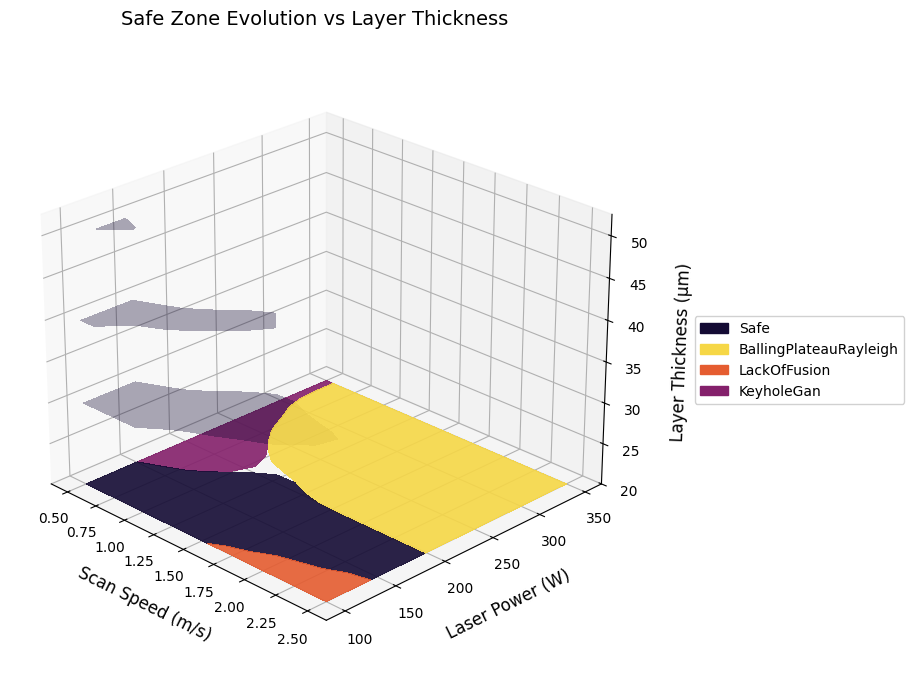

In [8]:
# Plot the 3D safe zone evolution vs layer thickness
# Each layer in the 3D plot corresponds to a different powder layer depth
fig, ax = space_lt.plot_3d_safe_zone(
    x_axis='scan_speed',
    y_axis='laser_power',
    z_axis='layer_thickness'
)

# Uncomment to save:
# fig, ax = space_lt.plot_3d_safe_zone(
#     x_axis='scan_speed', y_axis='laser_power', z_axis='layer_thickness',
#     save_path='ti64_3d_layer_thickness.png'
# )

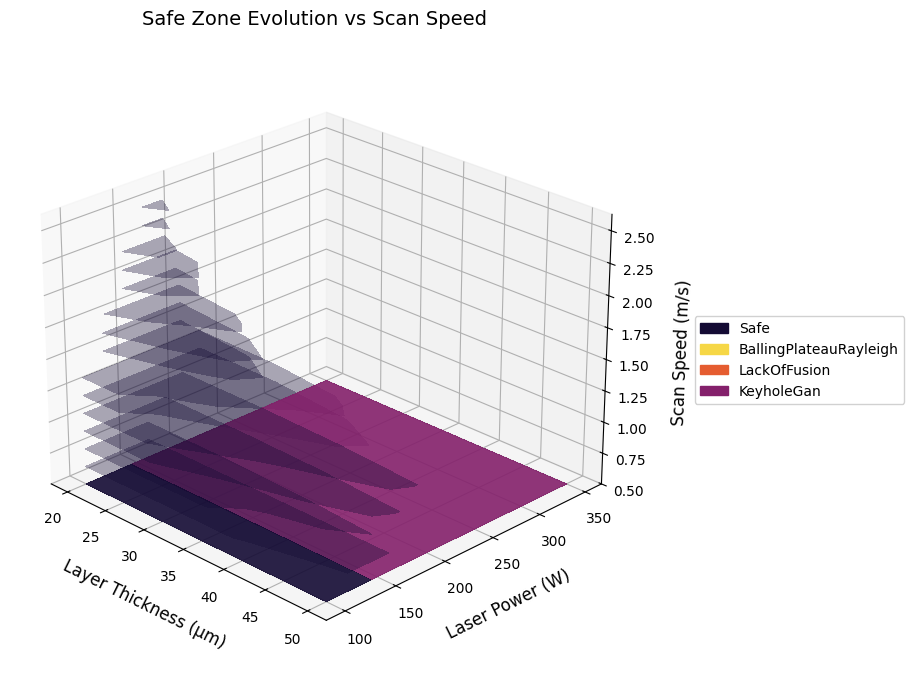

In [9]:
# Change the axes to show the 3D safe zone evolution vs layer thickness
fig, ax = space_lt.plot_3d_safe_zone(
    x_axis='layer_thickness',
    y_axis='laser_power',
    z_axis='scan_speed'
)

---

## Summary

The 3D safe zone plot is created by:
1. Building a 3D `ProcessParameters` grid using three `np.newaxis`-shaped vectors.
2. Running `PrintabilitySpace.evaluate()` — same API as the 2D case, no changes needed.
3. Calling `space.plot_3d_safe_zone(x_axis=..., y_axis=..., z_axis=...)` with
   `ProcessParameters` field names.

| Third axis | Physical meaning | Key observable |
|---|---|---|
| `beam_radius` | Spot size (optics) | Larger spot expands safe zone at same power |
| `layer_thickness` | Powder bed depth | Thicker layers shrink safe zone (more LOF) |

Any other `ProcessParameters` field (e.g., `hatch_spacing`, `ambient_temperature`) can be
used as the third axis by following the same broadcasting pattern.